# Laboratories 1 -- first steps into differential equations

### Solving ODEs in Python -- part 1: symbolical solutions

To solve ODEs symbolically, we need the library ```sympy```.

In [1]:
# !pip install sympy

In [1]:
import sympy

We will solve the equation
$$
x'=2t.
$$
First of all, we need to specify that $x$ and $t$ are symbols denoting a function and the independent variable, respectively.

In [2]:
from sympy import Function, symbols, dsolve, Eq, sqrt

t = symbols('t')
x = Function('x')

Next, we need something to denote the derivative of the function $x$

In [4]:
x(t).diff(t)

Derivative(x(t), t)

Now, we are ready to solve the equation.

In [5]:
# We need to write the equation in the form x'-f(t,x)=0, then the left-hand side is the first argument of the function
# dsolve, and then we need to specify the dependent variable, i.e. the function we want to solve the equation for.

eq = Eq(x(t).diff(t), 2 * t)
sol = dsolve(eq, x(t))
sol

Eq(x(t), C1 + t**2)

#### Task 3
Solve the following equations.
- $x'=5x$
- $x'=rx\left(1-\frac{x}{K}\right)$
- $x'=rx(a-x)\left(1-\frac{x}{K}\right)$

Is it possible to write the formula for the solution to the last equation in the form $'x(t)='$?

In [6]:
# I will use the notation from the above examples
eq_0 = Eq(x(t).diff(t), 5 * x(t))
sol_0 = dsolve(eq_0, x(t))
sol_0

Eq(x(t), C1*exp(5*t))

In [7]:
r, a, K = symbols('r a K')
eq_1 = Eq(x(t).diff(t), r * x(t) * (1 - x(t) / K))
sol_1 = dsolve(eq_1, x(t))
sol_1

Eq(x(t), K*exp(C1*K + r*t)/(exp(C1*K + r*t) - 1))

In [8]:
eq_2 = Eq(x(t).diff(t), r * x(t) * (a - x(t)) * (1 - x(t) / K))
sol_2 = dsolve(eq_2, x(t))
sol_2

Eq(log(x(t) + (2*K**6/(-K + a)**2 - 6*K**5*a/(-K + a)**2 + 8*K**4*a**2/(-K + a)**2 + 3*K**4*a/(-K + a) - 2*K**4 - 6*K**3*a**3/(-K + a)**2 - 6*K**3*a**2/(-K + a) + 3*K**3*a + 2*K**2*a**4/(-K + a)**2 + 3*K**2*a**3/(-K + a) - 2*K**2*a**2 + 3*K*a**3 - 2*a**4)/(2*K**3 - 3*K**2*a - 3*K*a**2 + 2*a**3))/(a*(-K + a)) - r*t/K - log(x(t) + (2*K**4*a**2/(-K + a)**2 - 2*K**4 - 6*K**3*a**3/(-K + a)**2 - 3*K**3*a**2/(-K + a) + 3*K**3*a + 8*K**2*a**4/(-K + a)**2 + 6*K**2*a**3/(-K + a) - 2*K**2*a**2 - 6*K*a**5/(-K + a)**2 - 3*K*a**4/(-K + a) + 3*K*a**3 + 2*a**6/(-K + a)**2 - 2*a**4)/(2*K**3 - 3*K**2*a - 3*K*a**2 + 2*a**3))/(K*(-K + a)) + log(x(t))/(K*a), C1)

#### Task 4 -- an equation with non-unique solutions
Let us consider the equation
$$
x'=\sqrt[3]{x^2}.
$$
This is an example of an equation which does not have unique solutions. Solve this equation and give an example of two different solutions $x_1(t), x_2(t)$ passing through the point $(0,0)$, i.e., such that $x_1(0)=x_2(0)=0$. Then, see what happens when you solve it in Python.

Solve the equation:
$$x' = \sqrt[3]{x^2}$$

1. We write the derivative and split the variables:
$$\frac{dx}{dt} = x^{\frac{2}{3}}$$
$$x^{-\frac{2}{3}} dx = dt$$

2. Integrate both sides:
$$\int x^{-\frac{2}{3}} dx = \int 1 dt$$

3. Result of integration:
$$3x^{\frac{1}{3}} = t + C$$

4. Transform to the form $x(t)$:
$$x(t) = \left(\frac{t+C}{3}\right)^3$$

5. Consider the initial condition $x(0) = 0$, to obtain constant $C$:
$$0 = \left(\frac{0+C}{3}\right)^3 \implies C = 0$$

We do have our **first solution**:
$$x_1(t) = \frac{t^3}{27}$$

Remembering about our fist step (division by $x$), we have to consider the trivial solution. So our **second solution** is:
$$x_2(t) = 0$$

In [5]:
eq_3 = Eq(x(t).diff(t), x(t) ** (2 / 3))
sol_3 = dsolve(eq_3, x(t), ics={x(0): 0})
sol_3

Eq(x(t), t**3/27)

### Initial value problems (IVPs)

As we have already observed, a solution to an ODE is in fact a family of functions. To choose one of them, we need to speicfy some additional condition the solution should satisfy, the so-called initial condition, for example, the initial position, speed, size of the population etc. Such equation together with an initial condition is called an initial value problem.

The function ```dsolve``` takes an additional argument which allows to specify the initial condition.

In [6]:
sol = dsolve(x(t).diff(t) - 2 * t, x(t), ics={x(0): 5})
sol

Eq(x(t), t**2 + 5)

We are ready to plot some solutions. We can turn a symbolical solution $x(t)$ into a Python function using ```lambdify```.

In [7]:
from sympy import lambdify

lam_sol = lambdify(t, sol.rhs)
lam_sol

<function _lambdifygenerated(t)>

In [8]:
lam_sol(0)  ## checking the initial condition

5

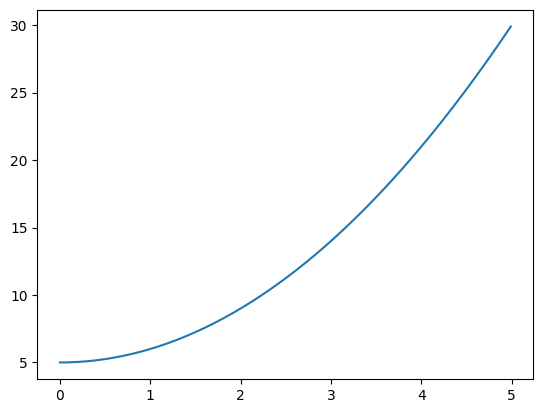

In [9]:
import matplotlib.pyplot as plt
import numpy as np

times = np.arange(0, 5, 0.01)

plt.plot(times, [lam_sol(t) for t in times])
plt.show()

#### Task 5
Let us consider the Verhulst model describing the evolution of the size of a population:
$$
x'=rx\left(1-\frac{x}{K}\right).
$$
The parameter $r$ describes the rate of growth of the population, while $K$ is the carrying capacity -- the maximal number of individuals that can coexist in the environment due to limited resources.
- Let $r=1$ and $K=2$. Plot in one figure the solutions with initial conditions $x(0)=1, x(0)=3, x(0)=2$.
- Do the same for $K=5, x(0)=4, x(0)=7, x(0)=5$.

What can you say about the behaviour of the solutions? How it is related to the value of $K$?

In [10]:
def verhulst(K, initial):
    eq_ver = Eq(x(t).diff(t), x(t) * (1 - x(t) / K))  # Here r = 1, so there is no other multiplication with x(t)
    sol_ver = dsolve(eq_ver, x(t), ics={x(0): initial})
    return lambdify(t, sol_ver.rhs)

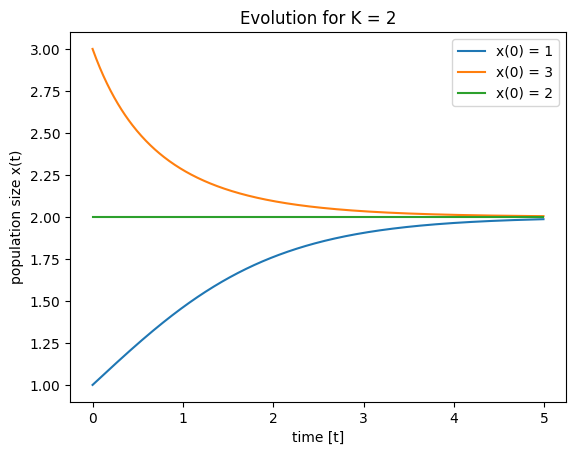

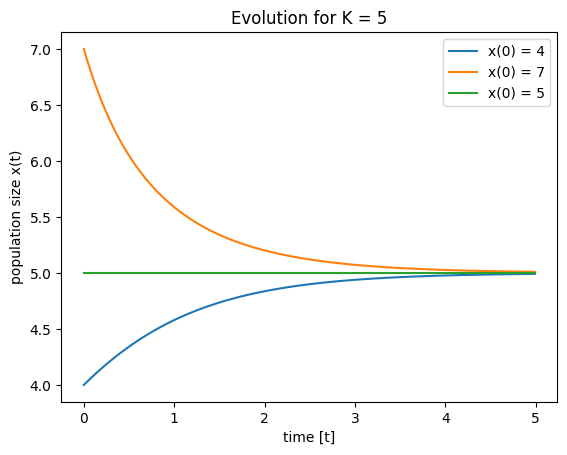

In [11]:
# Generate the plots for Verhulst function

times = np.arange(0, 5, 0.01)

K1 = 2
x0_case1 = [1, 3, 2]

K2 = 5
x0_case2 = [4, 7, 5]

functions_1 = [verhulst(K1, x0) for x0 in x0_case1]
functions_2 = [verhulst(K2, x0) for x0 in x0_case2]

# Plot for K = 2
for i in range(3):
    plt.plot(times, [functions_1[i](t) for t in times], label=f'x(0) = {x0_case1[i]}')

plt.title('Evolution for K = 2')
plt.xlabel('time [t]')
plt.ylabel('population size x(t)')
plt.legend()
plt.show()

# Plot for K = 5
for i in range(3):
    plt.plot(times, [functions_2[i](t) for t in times], label=f'x(0) = {x0_case2[i]}')

plt.title('Evolution for K = 5')
plt.xlabel('time [t]')
plt.ylabel('population size x(t)')
plt.legend()
plt.show()
